
# NLP TEXT ANALYZER

A Jupyter Notebook NLP application based on the topics in the supplied lectures:

**Tokenization → Corpus / Stopwords → POS Tagging → Stemming → Lemmatization → Morphology → NER**

This version includes an **automatic demonstration**, so you will see output after running the analysis cell even if Jupyter widgets are unavailable.


## STEP 1 — Install required libraries

In [1]:
%pip install -q spacy nltk pandas matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


## STEP 2 — Download NLP resources

In [2]:

import sys
import subprocess
import nltk

subprocess.run(
    [sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
    check=True
)

nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

print("✓ NLP resources are ready.")


✓ NLP resources are ready.


## STEP 3 — Import libraries

In [3]:

from collections import Counter

import spacy
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from IPython.display import display, HTML

nlp = spacy.load("en_core_web_sm")
stemmer = PorterStemmer()
nltk_stopwords = set(stopwords.words("english"))

print("✓ spaCy model loaded")
print("✓ Porter Stemmer loaded")
print("✓ NLTK stopword list loaded")


Matplotlib is building the font cache; this may take a moment.


✓ spaCy model loaded
✓ Porter Stemmer loaded
✓ NLTK stopword list loaded



## STEP 4 — NLP analysis engine

The engine extracts tokens, POS tags, lemmas, stems, stopword status,
named entities, morphology and corpus statistics.


In [4]:

def analyze_text(text):
    if not text or not text.strip():
        raise ValueError("Please enter some text.")

    doc = nlp(text)
    nltk_tokens = word_tokenize(text)

    entity_map = {}
    for ent in doc.ents:
        for token in ent:
            entity_map[token.i] = ent.label_

    rows = []

    for token in doc:
        stem = stemmer.stem(token.text) if token.is_alpha else token.text

        rows.append({
            "Token": token.text,
            "POS": token.pos_,
            "Fine POS": token.tag_,
            "Lemma": token.lemma_,
            "Stem": stem,
            "Stopword": "YES" if token.is_stop else "NO",
            "Entity": entity_map.get(token.i, ""),
            "Morphology": str(token.morph) if str(token.morph) else "—"
        })

    table = pd.DataFrame(rows)

    words = [t.text.lower() for t in doc if t.is_alpha]

    return {
        "doc": doc,
        "nltk_tokens": nltk_tokens,
        "table": table,
        "frequencies": Counter(words),
        "statistics": {
            "Characters": len(text),
            "Sentences": len(list(doc.sents)),
            "Total Tokens": len([t for t in doc if not t.is_space]),
            "Word Tokens": len(words),
            "Unique Words": len(set(words)),
            "Stopwords": sum(1 for t in doc if t.is_alpha and t.is_stop),
            "Named Entities": len(doc.ents),
            "Lexical Diversity": round(len(set(words)) / len(words), 3) if words else 0
        }
    }



## STEP 5 — Colour-coded text

**Green:** NER entity  
**Blue:** noun/proper noun  
**Purple:** verb  
**Orange:** adjective  
**Grey:** stopword  
**Red:** other token


In [5]:

def show_highlighted_text(doc):
    entity_map = {}

    for ent in doc.ents:
        for token in ent:
            entity_map[token.i] = ent.label_

    pieces = []

    for token in doc:
        if token.is_space:
            pieces.append(token.text)
            continue

        entity = entity_map.get(token.i, "")

        if entity:
            css = "entity"
            tooltip = f"Entity: {entity}"
        elif token.is_stop:
            css = "stop"
            tooltip = "Stopword"
        elif token.pos_ in {"NOUN", "PROPN"}:
            css = "noun"
            tooltip = f"POS: {token.pos_}"
        elif token.pos_ == "VERB":
            css = "verb"
            tooltip = "POS: VERB"
        elif token.pos_ == "ADJ":
            css = "adj"
            tooltip = "POS: ADJ"
        else:
            css = "other"
            tooltip = f"POS: {token.pos_}"

        safe = token.text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
        pieces.append(f'<span class="{css}" title="{tooltip}">{safe}</span>')

    html = '''
    <style>
    .nlp-box {font-size:18px; line-height:2.2; padding:18px; border:1px solid #bbb;
              border-radius:12px; background:#fafafa;}
    .nlp-box span {padding:4px 6px; margin:2px; border-radius:5px;}
    .entity {background:#b8f2c2; font-weight:bold;}
    .noun {background:#b9dcff;}
    .verb {background:#d9c4ff;}
    .adj {background:#ffd9a8;}
    .stop {background:#e5e5e5; color:#666;}
    .other {background:#ffc2c2;}
    </style>
    <div class="nlp-box">
    ''' + "".join(pieces) + '''
    </div>
    <p>
    <b>Legend:</b>
    <span style="background:#b8f2c2;padding:4px;">Entity</span>
    <span style="background:#b9dcff;padding:4px;">Noun</span>
    <span style="background:#d9c4ff;padding:4px;">Verb</span>
    <span style="background:#ffd9a8;padding:4px;">Adjective</span>
    <span style="background:#e5e5e5;padding:4px;">Stopword</span>
    </p>
    '''

    display(HTML(html))



# STEP 6 — RUN THIS CELL TO SEE OUTPUT

This is the important part: **the output is generated automatically**.
You do not have to click a widget to see the first result.


NLTK Tokens:
['Apple', 'hired', 'John', 'Smith', 'in', 'California', 'on', '12', 'August', '2026', '.', 'The', 'researchers', 'were', 'studying', 'new', 'language', 'models', ',', 'and', 'they', 'published', 'their', 'results', 'in', 'New', 'Delhi', '.']


,Token,POS,Fine POS,Lemma,Stem,Stopword,Entity,Morphology
0,Apple,PROPN,NNP,Apple,appl,NO,ORG,Number=Sing
1,hired,VERB,VBD,hire,hire,NO,,Tense=Past|VerbForm=Fin
2,John,PROPN,NNP,John,john,NO,PERSON,Number=Sing
3,Smith,PROPN,NNP,Smith,smith,NO,PERSON,Number=Sing
4,in,ADP,IN,in,in,YES,,—
5,California,PROPN,NNP,California,california,NO,GPE,Number=Sing
6,on,ADP,IN,on,on,YES,,—
7,12,NUM,CD,12,12,NO,DATE,NumType=Card
8,August,PROPN,NNP,August,august,NO,DATE,Number=Sing
9,2026,NUM,CD,2026,2026,NO,DATE,NumType=Card


Apple hired John Smith California August researchers studying new language models published results New Delhi


,Count
POS,
PROPN,7
NOUN,4
VERB,3
ADP,3
PUNCT,3
NUM,2
PRON,2
DET,1
AUX,1


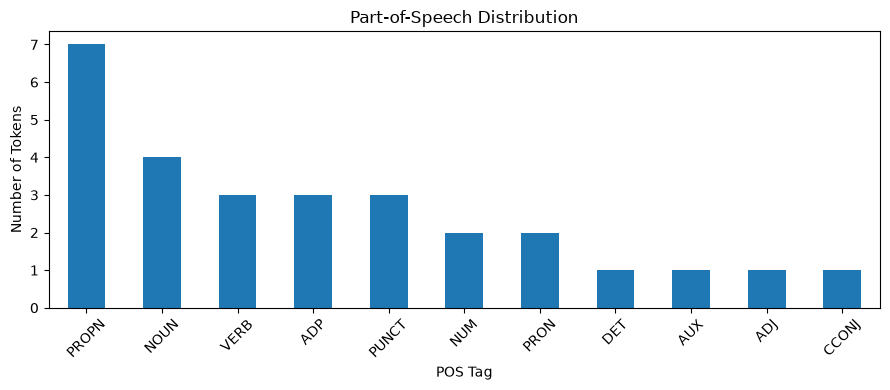

,Entity,Type,Meaning
0,Apple,ORG,"Companies, agencies, institutions, etc."
1,John Smith,PERSON,"People, including fictional"
2,California,GPE,"Countries, cities, states"
3,12 August 2026,DATE,Absolute or relative dates or periods
4,New Delhi,GPE,"Countries, cities, states"


,Token,POS,Stem,Lemma
0,Apple,PROPN,appl,Apple
1,hired,VERB,hire,hire
2,John,PROPN,john,John
3,Smith,PROPN,smith,Smith
4,in,ADP,in,in
5,California,PROPN,california,California
6,on,ADP,on,on
8,August,PROPN,august,August
11,The,DET,the,the
12,researchers,NOUN,research,researcher


,Word,Frequency
0,in,2
1,new,2
2,apple,1
3,hired,1
4,john,1
5,smith,1
6,california,1
7,on,1
8,august,1
9,the,1


,Token,POS,Lemma,Morphology
0,Apple,PROPN,Apple,Number=Sing
1,hired,VERB,hire,Tense=Past|VerbForm=Fin
2,John,PROPN,John,Number=Sing
3,Smith,PROPN,Smith,Number=Sing
4,in,ADP,in,—
5,California,PROPN,California,Number=Sing
6,on,ADP,on,—
7,12,NUM,12,NumType=Card
8,August,PROPN,August,Number=Sing
9,2026,NUM,2026,NumType=Card


✓ ANALYSIS COMPLETE


In [6]:

DEMO_TEXT = (
    "Apple hired John Smith in California on 12 August 2026. "
    "The researchers were studying new language models, and they published "
    "their results in New Delhi."
)

result = analyze_text(DEMO_TEXT)

display(HTML("<h1 style='text-align:center;'>NLP TEXT ANALYZER — RESULTS</h1>"))

# 1. Statistics
display(HTML("<h2>1. Corpus / Document Statistics</h2>"))

stats_html = "<div style='display:flex;flex-wrap:wrap;gap:10px;'>"
for key, value in result["statistics"].items():
    stats_html += f'''
    <div style="border:1px solid #bbb;border-radius:10px;padding:12px;
                min-width:130px;background:#f7f7f7;">
        <div style="font-size:13px;">{key}</div>
        <div style="font-size:24px;font-weight:bold;">{value}</div>
    </div>
    '''
stats_html += "</div>"
display(HTML(stats_html))

# 2. Highlighting
display(HTML("<h2>2. Colour-Coded Analysis</h2>"))
show_highlighted_text(result["doc"])

# 3. Tokenization
display(HTML("<h2>3. Tokenization</h2>"))
print("NLTK Tokens:")
print(result["nltk_tokens"])

# 4. Main table
display(HTML("<h2>4. Complete NLP Token Analysis</h2>"))
display(result["table"])

# 5. Stopwords
display(HTML("<h2>5. Stopword Removal</h2>"))
without_stopwords = [
    t.text for t in result["doc"]
    if t.is_alpha and not t.is_stop
]
print(" ".join(without_stopwords))

# 6. POS
display(HTML("<h2>6. POS Tag Distribution</h2>"))
pos_counts = result["table"]["POS"].value_counts()
display(pos_counts.to_frame("Count"))

ax = pos_counts.plot(kind="bar", figsize=(9, 4), title="Part-of-Speech Distribution")
ax.set_xlabel("POS Tag")
ax.set_ylabel("Number of Tokens")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. NER
display(HTML("<h2>7. Named Entity Recognition</h2>"))
if result["doc"].ents:
    ner_table = pd.DataFrame([
        {
            "Entity": e.text,
            "Type": e.label_,
            "Meaning": spacy.explain(e.label_) or e.label_
        }
        for e in result["doc"].ents
    ])
    display(ner_table)
else:
    print("No named entities detected.")

# 8. Stemming vs Lemmatization
display(HTML("<h2>8. Stemming vs. Lemmatization</h2>"))
display(result["table"][
    result["table"]["Token"].str.contains(r"[A-Za-z]", regex=True, na=False)
][["Token", "POS", "Stem", "Lemma"]])

# 9. Frequency
display(HTML("<h2>9. Corpus Word Frequency</h2>"))
display(pd.DataFrame(
    result["frequencies"].most_common(15),
    columns=["Word", "Frequency"]
))

# 10. Morphology
display(HTML("<h2>10. Morphological Analysis</h2>"))
display(result["table"][["Token", "POS", "Lemma", "Morphology"]])

print("✓ ANALYSIS COMPLETE")



# STEP 7 — ANALYZE YOUR OWN TEXT

Change the text below and run this cell. This version does not depend on Jupyter widgets.


In [7]:

MY_TEXT = (
    "Microsoft announced that Priya Sharma will lead a new artificial "
    "intelligence project in Mumbai. The team is developing powerful "
    "language models and testing them with real customer data."
)

my_result = analyze_text(MY_TEXT)

display(HTML("<h2>Your Text — Colour-Coded Analysis</h2>"))
show_highlighted_text(my_result["doc"])

display(HTML("<h2>Complete Analysis Table</h2>"))
display(my_result["table"])

display(HTML("<h2>Named Entities</h2>"))
if my_result["doc"].ents:
    display(pd.DataFrame([
        {
            "Entity": e.text,
            "Type": e.label_,
            "Meaning": spacy.explain(e.label_) or e.label_
        }
        for e in my_result["doc"].ents
    ]))
else:
    print("No named entities detected.")

display(HTML("<h2>Text After Stopword Removal</h2>"))
print(" ".join(
    t.text for t in my_result["doc"]
    if t.is_alpha and not t.is_stop
))


,Token,POS,Fine POS,Lemma,Stem,Stopword,Entity,Morphology
0,Microsoft,PROPN,NNP,Microsoft,microsoft,NO,ORG,Number=Sing
1,announced,VERB,VBD,announce,announc,NO,,Tense=Past|VerbForm=Fin
2,that,SCONJ,IN,that,that,YES,,—
3,Priya,PROPN,NNP,Priya,priya,NO,PERSON,Number=Sing
4,Sharma,PROPN,NNP,Sharma,sharma,NO,PERSON,Number=Sing
5,will,AUX,MD,will,will,YES,,VerbForm=Fin
6,lead,VERB,VB,lead,lead,NO,,VerbForm=Inf
7,a,DET,DT,a,a,YES,,Definite=Ind|PronType=Art
8,new,ADJ,JJ,new,new,NO,,Degree=Pos
9,artificial,ADJ,JJ,artificial,artifici,NO,,Degree=Pos


,Entity,Type,Meaning
0,Microsoft,ORG,"Companies, agencies, institutions, etc."
1,Priya Sharma,PERSON,"People, including fictional"
2,Mumbai,GPE,"Countries, cities, states"


Microsoft announced Priya Sharma lead new artificial intelligence project Mumbai team developing powerful language models testing real customer data



# STEP 8 — OPTIONAL INTERACTIVE INPUT BOX

If ipywidgets works in your Jupyter installation, this gives you the
**Input Text → Analyze Text** interface. The automatic analysis above remains available even if widgets fail.


In [8]:

try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    text_input = widgets.Textarea(
        value=DEMO_TEXT,
        description="Text:",
        layout=widgets.Layout(width="100%", height="150px")
    )

    analyze_btn = widgets.Button(
        description="Analyze Text",
        button_style="primary"
    )

    app_output = widgets.Output()

    def run_app(_):
        with app_output:
            clear_output(wait=True)
            text = text_input.value.strip()

            if not text:
                print("Please enter text.")
                return

            app_result = analyze_text(text)
            show_highlighted_text(app_result["doc"])
            display(app_result["table"])

            if app_result["doc"].ents:
                display(pd.DataFrame([
                    {
                        "Entity": e.text,
                        "Type": e.label_,
                        "Meaning": spacy.explain(e.label_) or e.label_
                    }
                    for e in app_result["doc"].ents
                ]))

    analyze_btn.on_click(run_app)

    display(widgets.VBox([text_input, analyze_btn, app_output]))
    print("✓ Interactive analyzer loaded.")

except Exception:
    print("Widgets are unavailable. Use STEP 7 instead.")


✓ Interactive analyzer loaded.



# FINAL — SYLLABUS MAPPING

| Topic | Implementation |
|---|---|
| Tokenization | NLTK `word_tokenize()` + spaCy tokens |
| Corpus | Vocabulary, word frequency, lexical diversity and document statistics |
| Stopwords | NLTK English stopwords + spaCy stopword flags |
| POS Tagging | spaCy coarse and fine POS |
| Stemming | NLTK Porter Stemmer |
| Lemmatization | spaCy lemma |
| Morphology | spaCy morphological features |
| NER | spaCy `doc.ents` |
| Visualization | Colour-coded text, tables and POS chart |
